In [1]:
import numpy as np
import scipy as sp
from scipy import constants as cte
import matplotlib as mpl
import matplotlib.pyplot as plt
import numcosmo_sne.cosmology as cosmo
from pathlib import Path
figDir = Path("../outputs/figs/")

In [2]:
z = np.linspace(0,20,1000)

In [7]:
cosmo.cosmologicalExpansion(z, 0, 3) # Example of a non-physical cosmology with negative E²

NonPhysicalCosmologyError: Invalid expansion history for omega_m=0.000, omega_lambda=3.000, omega_r=0.000.

In [4]:
cosmo.FLRW(z, 1.2, 2.8) # Another example of non-physical cosmology, that passes the expansion test but yields negative distances (no defined distance modulus for all redshifts)

NonPhysicalCosmologyError: Luminosity distance became non-positive.

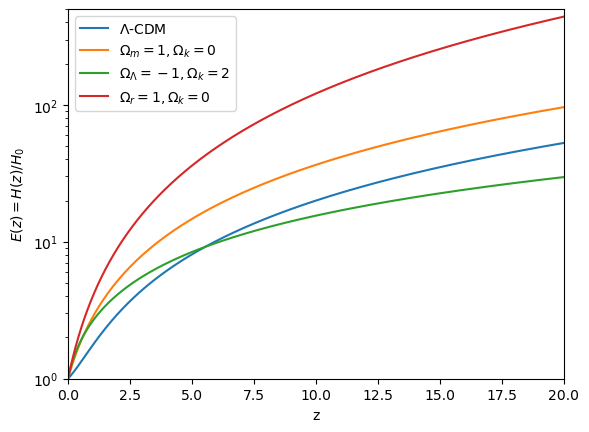

In [5]:
plt.plot(z, cosmo.cosmologicalExpansion(z, 0.3, 0.7),        label=r"$\Lambda$-CDM")
plt.plot(z, cosmo.cosmologicalExpansion(z, 1, 0),            label="$\Omega_m=1, \Omega_k=0$")
plt.plot(z, cosmo.cosmologicalExpansion(z, 0, -1),            label="$\Omega_\Lambda=-1, \Omega_k=2$")
plt.plot(z, cosmo.cosmologicalExpansion(z, 0, 0, omega_r=1), label="$\Omega_r=1, \Omega_k=0$")
plt.xlabel("z")
plt.ylabel("$E(z)=H(z)/H_0$")
plt.yscale("log")
plt.xlim(0,20)
plt.ylim(1, 5e+2)
plt.legend()
plt.savefig(figDir / "cosmExpansion.png", dpi=300)
plt.show()
plt.close()

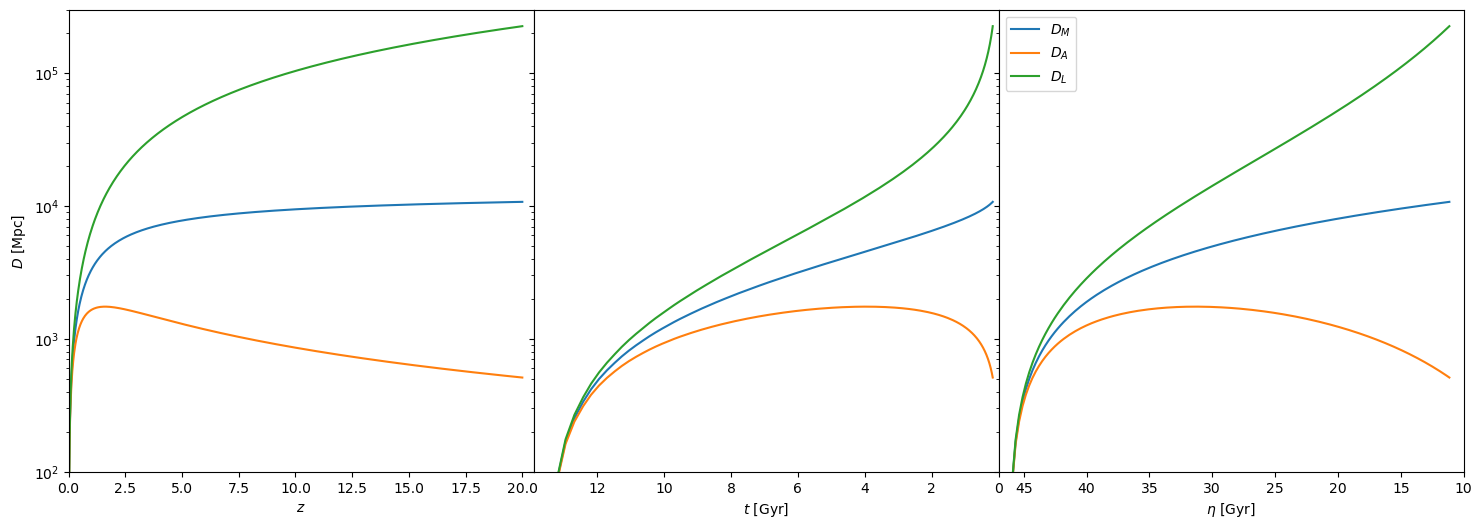

In [6]:
dist = cosmo.cosmologicalDistances(z, 70, 0.3, 0.7)
t, eta = cosmo.cosmologicalTime(z, 70, 0.3, 0.7)

fig, ax = plt.subplots(ncols=3, figsize=[18,6], sharey=True, gridspec_kw = {'wspace':0})

ax[0].plot(z, dist[1], c="C0")
ax[0].plot(z, dist[2], c="C1")
ax[0].plot(z, dist[3], c="C2")

ax[1].plot(t, dist[1], c="C0")
ax[1].plot(t, dist[2], c="C1")
ax[1].plot(t, dist[3], c="C2")

ax[2].plot(eta, dist[1], c="C0", label="$D_M$")
ax[2].plot(eta, dist[2], c="C1", label="$D_A$")
ax[2].plot(eta, dist[3], c="C2", label="$D_L$")

ax[0].set_xlabel("$z$")
ax[1].set_xlabel("$t$ [Gyr]")
ax[2].set_xlabel("$\eta$ [Gyr]")
ax[0].set_ylabel("$D$ [Mpc]")
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[2].set_yscale("log")

ax[0].set_xlim(0,20.5)
ax[1].set_xlim(13.9,0)
ax[2].set_xlim(47,10)
ax[0].set_ylim(1e+2,3e+5)

ax[2].legend()
plt.savefig(figDir / "cosmDistances.png", dpi=300)
plt.show()
plt.close()